# 单波形原始 VMD 分析

读取一个 Instantel ASCII/TXT 文件，从 `Tran`、`Vert`、`Long` 中选择一个完整波形，并使用原仓库 VMD 源码进行整段稳态分解。

## 1. 导入依赖

In [1]:
from dataclasses import dataclass
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy
from IPython.display import display
from numba import jit, prange
from scipy.fft import irfft, rfft
from tqdm import tqdm

## 2. 手动参数

`N_FFT` 沿用原仓库参数名，用于反射填充宽度，不是STVMD滑动时窗。

In [19]:
# 只在这里修改输入文件、方向和VMD参数。
INPUT_FILE = Path("15m.TXT")
DIRECTION = "Tran"

K = 7
ALPHA = 50.0
N_FFT = 64
TAU = 1e-5
TOL = 1e-9
MAX_ITERS = 10000

PLOT_MAX_HZ = 2048.0
SAVE_OUTPUTS = True

print(
    f"file={INPUT_FILE}, direction={DIRECTION}, K={K}, "
    f"alpha={ALPHA}, n_fft={N_FFT}, max_iters={MAX_ITERS}"
)

file=15m.TXT, direction=Tran, K=7, alpha=50.0, n_fft=64, max_iters=10000


## 3. 读取一个 TXT 波形

In [3]:
@dataclass(frozen=True)
class InstantelRecord:
    path: Path
    metadata: dict
    fs: float
    pretrigger_seconds: float
    data: np.ndarray


@dataclass(frozen=True)
class SingleWaveform:
    path: Path
    metadata: dict
    fs: float
    pretrigger_seconds: float
    direction: str
    time_s: np.ndarray
    values: np.ndarray


def _metadata_number(metadata, key):
    import re

    if key not in metadata:
        raise ValueError(f"缺少元数据字段: {key}")
    match = re.search(r"[-+]?\d+(?:\.\d+)?", metadata[key])
    if match is None:
        raise ValueError(f"无法解析元数据字段 {key}: {metadata[key]!r}")
    return float(match.group())


def load_instantel_txt(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"找不到输入文件: {path}")
    lines = path.read_text(
        encoding="utf-8-sig", errors="replace"
    ).splitlines()
    metadata = {}
    header_index = None
    for index, raw in enumerate(lines):
        stripped = raw.strip().strip('"')
        if all(name in stripped for name in ("Tran", "Vert", "Long")):
            header_index = index
            break
        if ":" in stripped:
            key, value = stripped.split(":", 1)
            metadata[key.strip()] = value.strip()
    if header_index is None:
        raise ValueError(f"{path.name}: 未找到 Tran/Vert/Long 数据表头")
    data = np.loadtxt(lines[header_index + 1 :], dtype=float)
    data = np.atleast_2d(data)
    if data.shape[1] != 3:
        raise ValueError(
            f"{path.name}: 期望3列数据，实际为{data.shape[1]}列"
        )
    if not np.isfinite(data).all():
        raise ValueError(f"{path.name}: 数据包含 NaN 或无穷值")
    fs = _metadata_number(metadata, "Sample Rate")
    pretrigger = abs(_metadata_number(metadata, "Pre-trigger Length"))
    if fs <= 0:
        raise ValueError(f"{path.name}: 采样率必须为正数")
    return InstantelRecord(
        path=path,
        metadata=metadata,
        fs=fs,
        pretrigger_seconds=pretrigger,
        data=data,
    )


def load_single_waveform(path, direction):
    direction_names = ("Tran", "Vert", "Long")
    if direction not in direction_names:
        raise ValueError(f"DIRECTION 必须为 {direction_names} 之一")
    record = load_instantel_txt(path)
    column = direction_names.index(direction)
    values = record.data[:, column].astype(float, copy=False)
    time_s = np.arange(values.size) / record.fs - record.pretrigger_seconds
    return SingleWaveform(
        path=record.path,
        metadata=record.metadata,
        fs=record.fs,
        pretrigger_seconds=record.pretrigger_seconds,
        direction=direction,
        time_s=time_s,
        values=values,
    )

## 4. 原仓库缓冲函数与 VMD 类

下面两个单元格逐字来自 `main_STVMD.ipynb`。

In [4]:
@jit(nopython=True, cache=True)
def _buffer(x, out, nfft, hop_len):
    for i in prange(0, x.shape[-1]-nfft+1, hop_len):
        out[:,:,i]=x[:,i:i+nfft]
def buffer(x, nfft, hop_len, modulated=True):
    # x: channel, time
    if np.ndim(x)==1:
        x = x.reshape(1,-1)
    out = np.zeros((x.shape[0], nfft, x.shape[-1]-nfft+1))
    _buffer(x, out, nfft, hop_len)
    if modulated:
        out = np.roll(out, int(np.ceil(nfft / 2)), 1)
    return out

@jit(nopython=True, cache=True)
def _unbuffer(x, xbuf, window, hop_len):
    for i in prange(xbuf.shape[2]):
        n = i * hop_len
        x[:, n:n + len(window)] += xbuf[:, :, i] * window
        
def unbuffer(xbuf, window, hop_len, win_exp=1):
    if np.ndim(xbuf)==2:
        xbuf=np.expand_dims(xbuf,0)
    if win_exp == 0:
        window = 1
    elif win_exp != 1:
        window = window ** win_exp
    x = np.zeros((xbuf.shape[0], xbuf.shape[1] + xbuf.shape[2] - 1), dtype=xbuf.dtype)

    _unbuffer(x, xbuf, window, hop_len)
    return x

@jit(nopython=True, cache=True)
def _window_norm(wn, window, hop_len, n_fft, win_exp=1):
    max_hops = (len(wn) - n_fft) // hop_len + 1
    wpow = window ** (win_exp + 1)
    for i in range(max_hops):
        n = i * hop_len
        wn[n:n + n_fft] += wpow

def window_norm(window, hop_len, n_fft, N, win_exp=1):
    wn = np.zeros(N + n_fft - 1)
    _window_norm(wn, window, hop_len, n_fft, win_exp)
    return wn

In [5]:
class VMD(object):
    def __init__(self, num_channel, n_fft= 128, alpha= 10, K= 3, init=1, tol=1e-05, tau= 0.1, maxiters=1000) -> None:
        self.alpha = alpha*np.ones(K)
        self.K=K
        self.n_fft = n_fft
        self.init=init
        self.tol=tol
        self.tau=tau
        self.maxiters = maxiters
        self.padwidth = ((n_fft-1)//2, (n_fft-1)//2) if (n_fft-1)%2==0 else ((n_fft-1)//2+1, (n_fft-1)//2)
        self.num_channel = num_channel
        self.u_hat_plus = None
        self.sum_uk = None
    
    def prepare_offline(self, x):
        assert np.ndim(x)<=2
        if np.ndim(x)==1:
            x = x.reshape(1, -1)
        self.len_x = x.shape[1]
        xp = np.pad(x, ([0, 0], self.padwidth), mode='reflect')
        f_hat_plus = rfft(xp, axis=1, workers=-1)
        return f_hat_plus
    
    def apply(self, f_hat_plus, omega=None):
        C, len_freqs = f_hat_plus.shape
        freqs = np.arange(1, len_freqs+1)/(len_freqs)
        omega_plus = np.zeros([self.maxiters, self.K])
        if omega is None:
            for i in range(self.K):
                omega_plus[0,i] = (1/self.K)*i
        else:
            omega_plus[0] = omega.ravel()
 
        u_hat_plus = np.zeros([self.maxiters, C, len_freqs, self.K],dtype=complex)
        sum_uk = np.zeros([C, len_freqs], dtype=complex)
        lambda_hat = np.zeros([self.maxiters, C, len_freqs], dtype = complex)
        
        pbar = tqdm(np.arange(self.maxiters-1))
        for iter in pbar:
            # n = np.mod(iter, 2)
            
            k = 0
            for c in np.arange(C):
                sum_uk[c,:] = u_hat_plus[np.mod(iter, 2), c,:,self.K-1] + sum_uk[c,:] - u_hat_plus[np.mod(iter, 2), c,:,0]
                u_hat_plus[np.mod(iter+1, 2), c,:,k] = (f_hat_plus[c, :] - sum_uk[c,:] - lambda_hat[np.mod(iter, 2), c,:]/2)/(1.+self.alpha[k]*(freqs - omega_plus[np.mod(iter, 2),k])**2)
            for k in np.arange(1,self.K):
                for c in np.arange(C):
                    sum_uk[c,:] = u_hat_plus[np.mod(iter+1, 2),c,:,k-1] + sum_uk[c,:] - u_hat_plus[np.mod(iter, 2),c,:,k]
                    u_hat_plus[np.mod(iter+1, 2),c,:,k] = (f_hat_plus[c,:] - sum_uk[c,:] - lambda_hat[np.mod(iter, 2),c,:]/2)/(1+self.alpha[k]*(freqs - omega_plus[np.mod(iter, 2),k])**2)
                # center frequencies
                if omega is not None:
                    omega_plus[np.mod(iter+1, 2),k] = omega_plus[0,k]
                else:
                    omega_plus[np.mod(iter+1, 2),k] = np.sum(np.einsum('j,ij', freqs,(abs(u_hat_plus[np.mod(iter+1, 2), :, :, k])**2)))/np.sum(abs(u_hat_plus[np.mod(iter+1, 2),:,:,k])**2)
            lambda_hat[np.mod(iter+1, 2),:,:] = lambda_hat[np.mod(iter, 2),:,:] + self.tau*(np.sum(u_hat_plus[np.mod(iter+1, 2),:,:,:],axis = 2)-f_hat_plus)

            uDiff = np.spacing(np.ones(self.K))
            for i in range(self.K):
                delta = u_hat_plus[0,:,i]-u_hat_plus[1,:,i]
                delta = delta.reshape(-1)
                uDiff[i] = (1/len(delta))*np.dot(delta,np.conj(delta)).real
            # for i in range(self.K):
            #     uDiff = uDiff + np.power(u_hat_plus[np.mod(iter, 2)]-u_hat_plus[np.mod(iter-1, 2)], 2).sum()/(len_freqs*self.K*C)
            uDiff = uDiff.mean(-1)
            if uDiff < self.tol and iter>2:
                break
            pbar.set_description("Processing "  + "{:10.9f}".format(uDiff) + ":")
        u_hat = u_hat_plus[np.mod(iter, 2)]
        omega = omega_plus[np.mod(iter, 2)]
        seqw = np.argsort(omega)
        u_hat = u_hat[:,:,seqw]
        omega = omega[seqw]
        return u_hat, omega
    
    def postprocess(self, u_hat):
        u = irfft(u_hat, n=self.len_x+np.sum(self.padwidth), axis=1, workers=-1).real
        u = np.transpose(u, (2, 0, 1))
        u = u[:, :, self.padwidth[0]:-self.padwidth[1]]
        return u

## 5. VMD适配、诊断和绘图

In [6]:
def validate_vmd_config(K, alpha, n_fft, tau, tol, max_iters):
    if not isinstance(K, (int, np.integer)) or K < 2:
        raise ValueError("K 必须为不小于2的整数")
    if not isinstance(n_fft, (int, np.integer)) or n_fft < 2:
        raise ValueError("N_FFT 必须为不小于2的整数")
    if not isinstance(max_iters, (int, np.integer)) or max_iters < 2:
        raise ValueError("MAX_ITERS 必须为不小于2的整数")
    for name, value in (
        ("ALPHA", alpha),
        ("TAU", tau),
        ("TOL", tol),
    ):
        if not np.isfinite(value) or value <= 0:
            raise ValueError(f"{name} 必须为有限正数")


def estimate_original_vmd_memory_gb(
    channels, samples, K, n_fft, max_iters
):
    left = n_fft // 2
    right = n_fft - 1 - left
    padded_samples = samples + left + right
    frequency_bins = padded_samples // 2 + 1
    complex_bytes = 16
    float_bytes = 8
    u_bytes = (
        max_iters * channels * frequency_bins * K * complex_bytes
    )
    lambda_bytes = (
        max_iters * channels * frequency_bins * complex_bytes
    )
    omega_bytes = max_iters * K * float_bytes
    return (u_bytes + lambda_bytes + omega_bytes) / (1024 ** 3)


def run_original_vmd(
    x,
    fs,
    K=4,
    alpha=50.0,
    n_fft=64,
    tau=1e-5,
    tol=1e-9,
    max_iters=10000,
):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2 or not np.isfinite(x).all():
        raise ValueError("输入必须为有限的 (通道, 时间) 二维数组")
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError("采样率必须为有限正数")
    validate_vmd_config(K, alpha, n_fft, tau, tol, max_iters)
    model = VMD(
        num_channel=x.shape[0],
        n_fft=n_fft,
        alpha=alpha,
        K=K,
        tol=tol,
        tau=tau,
        maxiters=max_iters,
    )
    spectrum = model.prepare_offline(x)
    mode_spectrum, omega = model.apply(spectrum)
    modes = model.postprocess(mode_spectrum)
    return {
        "modes": modes,
        "mode_spectrum": mode_spectrum,
        "center_freq_hz": omega * (fs / 2.0),
    }

In [7]:
def _energy_band(freq_hz, power, low=0.05, high=0.95):
    power = np.maximum(np.asarray(power, dtype=float), 0.0)
    total = float(np.sum(power))
    if total <= np.finfo(float).eps:
        return np.array([0.0, 0.0])
    cumulative = np.cumsum(power) / total
    return np.array(
        [
            np.interp(low, cumulative, freq_hz),
            np.interp(high, cumulative, freq_hz),
        ]
    )


def summarize_vmd_result(x, fs, raw):
    modes = raw["modes"]
    reconstruction = np.sum(modes, axis=0)
    denominator = np.linalg.norm(x, axis=1)
    nrmse = np.divide(
        np.linalg.norm(x - reconstruction, axis=1),
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > np.finfo(float).eps,
    )
    mode_energy = np.sum(modes ** 2, axis=2)
    energy_total = np.sum(mode_energy, axis=0, keepdims=True)
    energy_fraction = np.divide(
        mode_energy,
        energy_total,
        out=np.zeros_like(mode_energy),
        where=energy_total > np.finfo(float).eps,
    )
    frequency_hz = scipy.fft.rfftfreq(
        modes.shape[-1], d=1.0 / fs
    )
    mode_power = np.zeros((modes.shape[0], frequency_hz.size))
    frequency_bands_hz = np.zeros((modes.shape[0], 2))
    for mode in range(modes.shape[0]):
        spectra = scipy.fft.rfft(modes[mode], axis=1, workers=-1)
        mode_power[mode] = np.sum(np.abs(spectra) ** 2, axis=0)
        frequency_bands_hz[mode] = _energy_band(
            frequency_hz, mode_power[mode]
        )
    result = dict(raw)
    result.update(
        {
            "reconstruction": reconstruction,
            "nrmse": nrmse,
            "energy_fraction": energy_fraction,
            "frequency_hz": frequency_hz,
            "mode_power": mode_power,
            "frequency_bands_hz": frequency_bands_hz,
        }
    )
    return result

In [8]:
def _mode_color(mode):
    return plt.get_cmap("tab10")(mode % 10)


def _component_label(mode):
    return "Residual" if mode == 0 else f"Mode {mode}"


def plot_input_and_modes(waveform, result):
    modes = result["modes"][:, 0, :]
    fig, axes = plt.subplots(
        modes.shape[0] + 1,
        1,
        figsize=(11, 2.0 * (modes.shape[0] + 1)),
        sharex=True,
        constrained_layout=True,
    )
    axes[0].plot(
        waveform.time_s, waveform.values, color="#475569", lw=0.8
    )
    axes[0].set_ylabel("Input\nVelocity (mm/s)")
    axes[0].set_title(
        f"{waveform.path.name} {waveform.direction}: original VMD"
    )
    for mode in range(modes.shape[0]):
        axes[mode + 1].plot(
            waveform.time_s,
            modes[mode],
            color=_mode_color(mode),
            lw=0.75,
        )
        axes[mode + 1].set_ylabel(
            f"{_component_label(mode)}\nVelocity (mm/s)"
        )
    for axis in axes:
        axis.axvline(0, color="black", ls="--", lw=0.6)
    axes[-1].set_xlabel("Time (s)")
    return fig


def plot_center_frequencies(waveform, result, plot_max_hz):
    center = result["center_freq_hz"]
    labels = [_component_label(mode) for mode in range(center.size)]
    fig, axis = plt.subplots(
        1, 1, figsize=(10, 4.2), constrained_layout=True
    )
    bars = axis.bar(
        np.arange(center.size),
        center,
        color=[_mode_color(mode) for mode in range(center.size)],
    )
    axis.set(
        xlabel="Component",
        ylabel="Center frequency (Hz)",
        title="Constant VMD center frequencies",
        ylim=(0.0, min(float(plot_max_hz), waveform.fs / 2.0)),
    )
    axis.set_xticks(np.arange(center.size), labels)
    axis.bar_label(bars, fmt="%.2f Hz", fontsize=9)
    return fig


def plot_reconstruction_and_energy(waveform, result):
    mode_n = result["modes"].shape[0]
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(11, 7),
        gridspec_kw={"height_ratios": (1.4, 1.0)},
        constrained_layout=True,
    )
    axes[0].plot(
        waveform.time_s,
        waveform.values,
        color="#64748b",
        lw=0.8,
        label="Input",
    )
    axes[0].plot(
        waveform.time_s,
        result["reconstruction"][0],
        color="#D55E00",
        lw=0.7,
        label="Reconstruction",
    )
    axes[0].axvline(0, color="black", ls="--", lw=0.6)
    axes[0].set(
        xlabel="Time (s)",
        ylabel="Velocity (mm/s)",
        title=f"Reconstruction  NRMSE={result['nrmse'][0]:.3g}",
    )
    axes[0].legend(frameon=False)
    fractions = result["energy_fraction"][:, 0]
    bars = axes[1].bar(
        np.arange(mode_n),
        fractions,
        color=[_mode_color(mode) for mode in range(mode_n)],
    )
    axes[1].set(
        xlabel="Component",
        ylabel="Energy fraction",
        title="Component energy fraction",
    )
    axes[1].set_xticks(
        np.arange(mode_n),
        [_component_label(mode) for mode in range(mode_n)],
    )
    axes[1].bar_label(bars, fmt="%.3f", fontsize=9)
    return fig


def plot_mode_spectra(waveform, result, plot_max_hz):
    mode_n = result["modes"].shape[0]
    fig, axis = plt.subplots(
        1, 1, figsize=(11, 5.2), constrained_layout=True
    )
    for mode in range(mode_n):
        low, high = result["frequency_bands_hz"][mode]
        axis.plot(
            result["frequency_hz"],
            result["mode_power"][mode],
            color=_mode_color(mode),
            lw=0.9,
            label=(
                f"{_component_label(mode)}: "
                f"{low:.1f}-{high:.1f} Hz"
            ),
        )
        axis.axvline(low, color=_mode_color(mode), ls=":", lw=0.6)
        axis.axvline(high, color=_mode_color(mode), ls=":", lw=0.6)
    axis.set(
        xlabel="Frequency (Hz)",
        ylabel="Power",
        title="VMD component spectra",
        xlim=(0.0, min(float(plot_max_hz), waveform.fs / 2.0)),
    )
    axis.legend(frameon=False, fontsize=8)
    return fig


def plot_vmd_results(waveform, result):
    return {
        "input_modes": plot_input_and_modes(waveform, result),
        "center_frequencies": plot_center_frequencies(
            waveform, result, PLOT_MAX_HZ
        ),
        "reconstruction_energy": plot_reconstruction_and_energy(
            waveform, result
        ),
        "mode_spectra": plot_mode_spectra(
            waveform, result, PLOT_MAX_HZ
        ),
    }

In [9]:
def analyze_single_waveform_vmd(waveform):
    raw = run_original_vmd(
        waveform.values.reshape(1, -1),
        fs=waveform.fs,
        K=K,
        alpha=ALPHA,
        n_fft=N_FFT,
        tau=TAU,
        tol=TOL,
        max_iters=MAX_ITERS,
    )
    return summarize_vmd_result(
        waveform.values.reshape(1, -1), waveform.fs, raw
    )


def save_vmd_results(output_dir, waveform, result, figures):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = waveform.direction.lower()
    for name, figure in figures.items():
        figure.savefig(
            output_dir / f"{prefix}_{name}.png",
            dpi=300,
            bbox_inches="tight",
        )
    np.savez_compressed(
        output_dir / "vmd_single_waveform_results.npz",
        input_file=str(waveform.path),
        direction=waveform.direction,
        fs=waveform.fs,
        time_s=waveform.time_s,
        modes=result["modes"],
        center_freq_hz=result["center_freq_hz"],
        reconstruction=result["reconstruction"],
        nrmse=result["nrmse"],
        energy_fraction=result["energy_fraction"],
        frequency_bands_hz=result["frequency_bands_hz"],
    )

## 6. 运行完整波形 VMD

C:\Users\admin\AppData\Local\Temp\ipykernel_6488\3611976920.py:16: RuntimeWarning: 当前参数的原始VMD内存估算超过2 GB；请考虑降低MAX_ITERS或K。
  warnings.warn(


文件: D:\BaiduNetdiskDownload\vmd\Short-Time-Variational-Mode-Decomposition\15m.TXT
方向: Tran
采样率: 4096.0 Hz
样本数: 23176
时间范围: (-0.5, 5.157958984375) s
原始VMD粗略内存估算: 13.85 GB


Processing 0.000000000::   0%|          | 3/9999 [00:00<00:38, 257.55it/s]


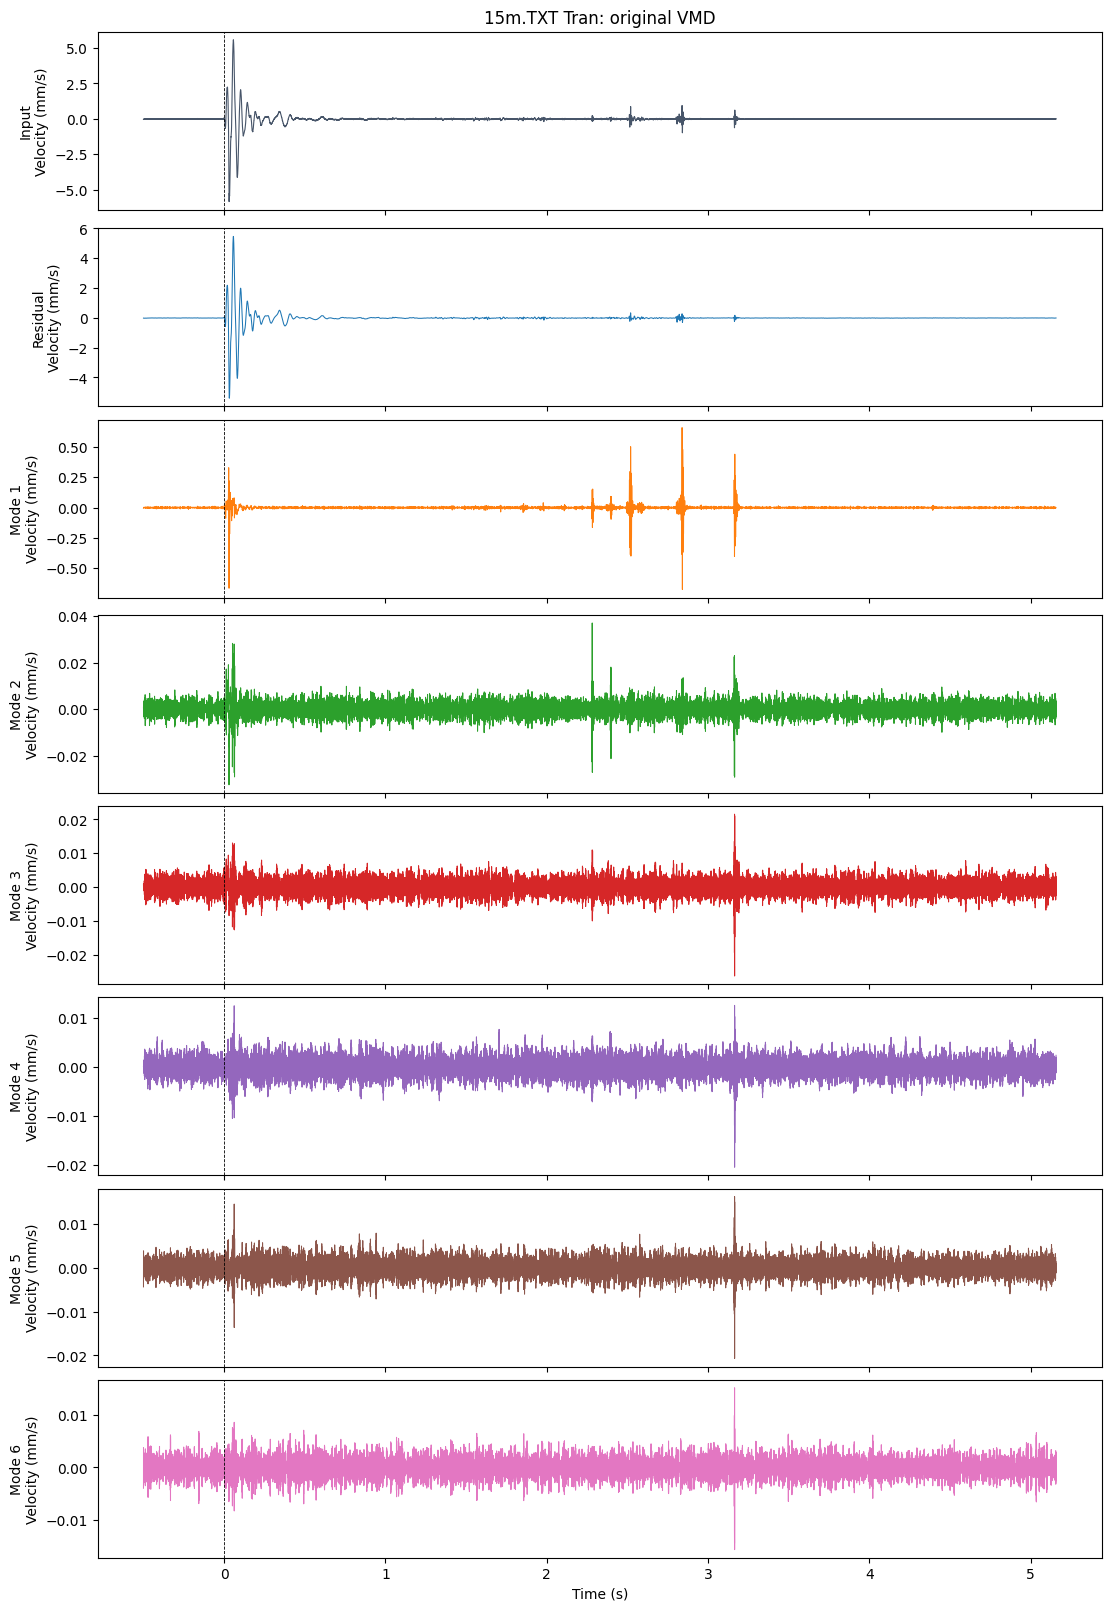

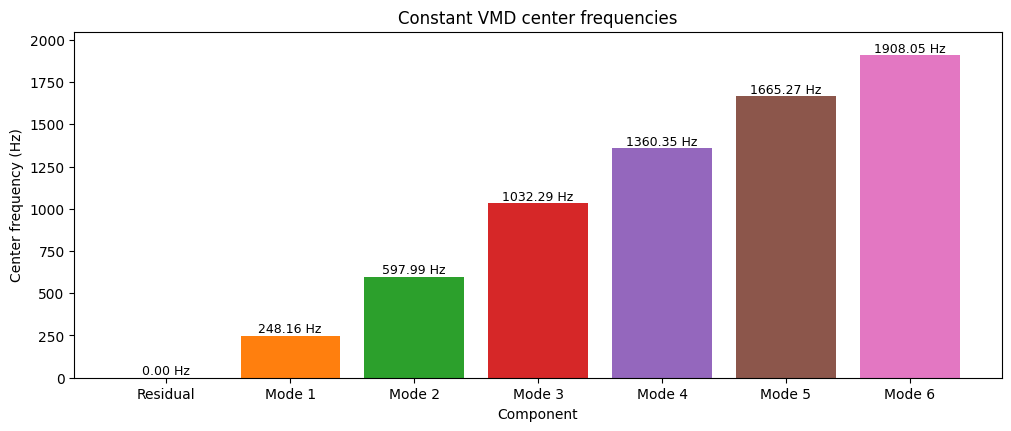

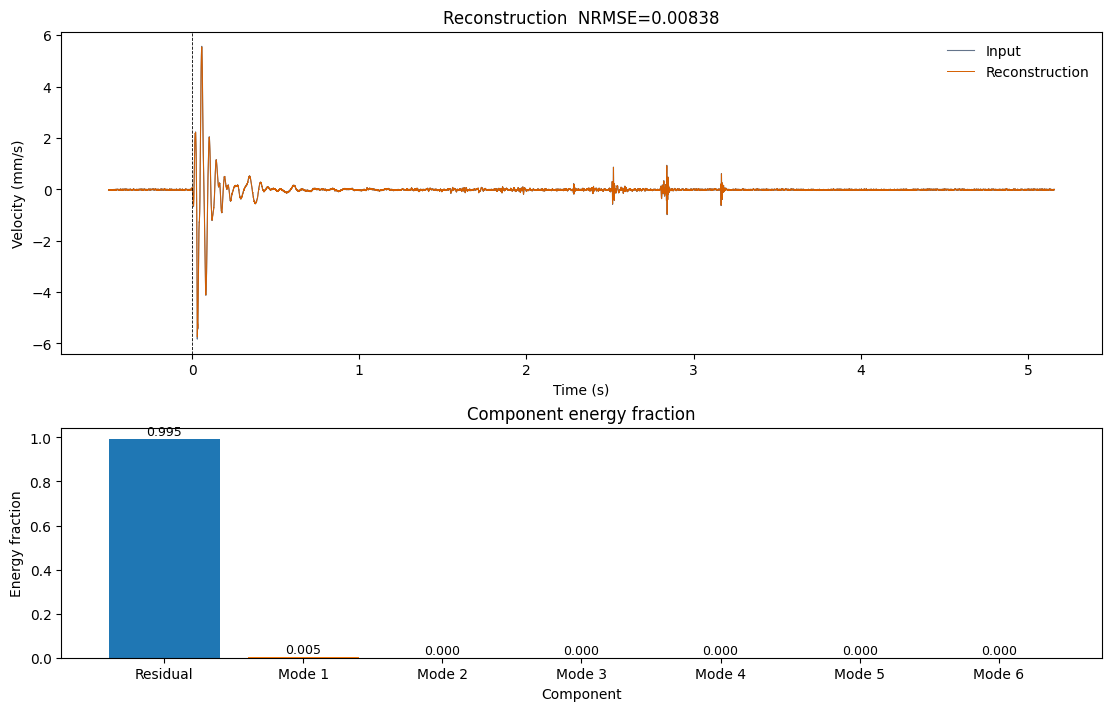

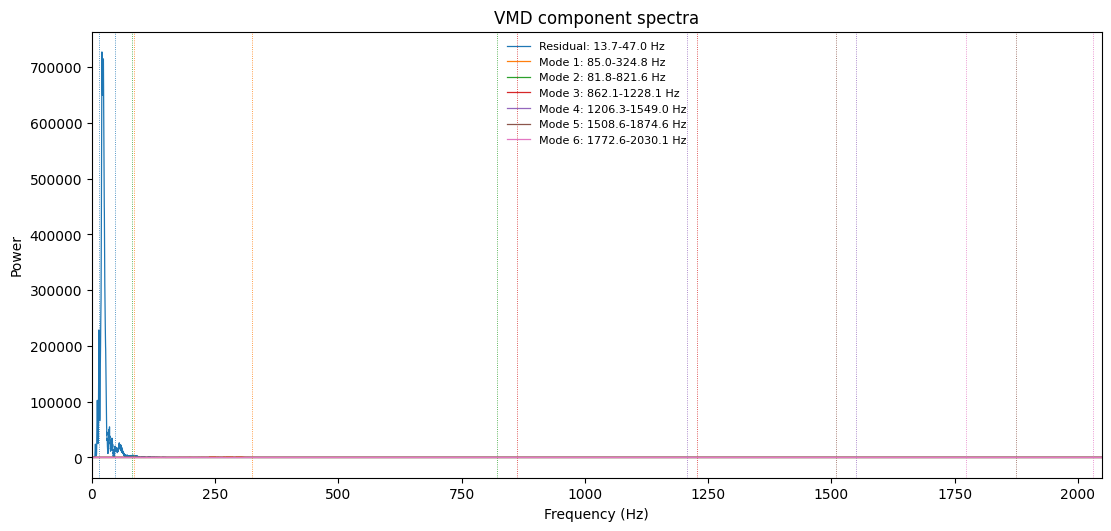

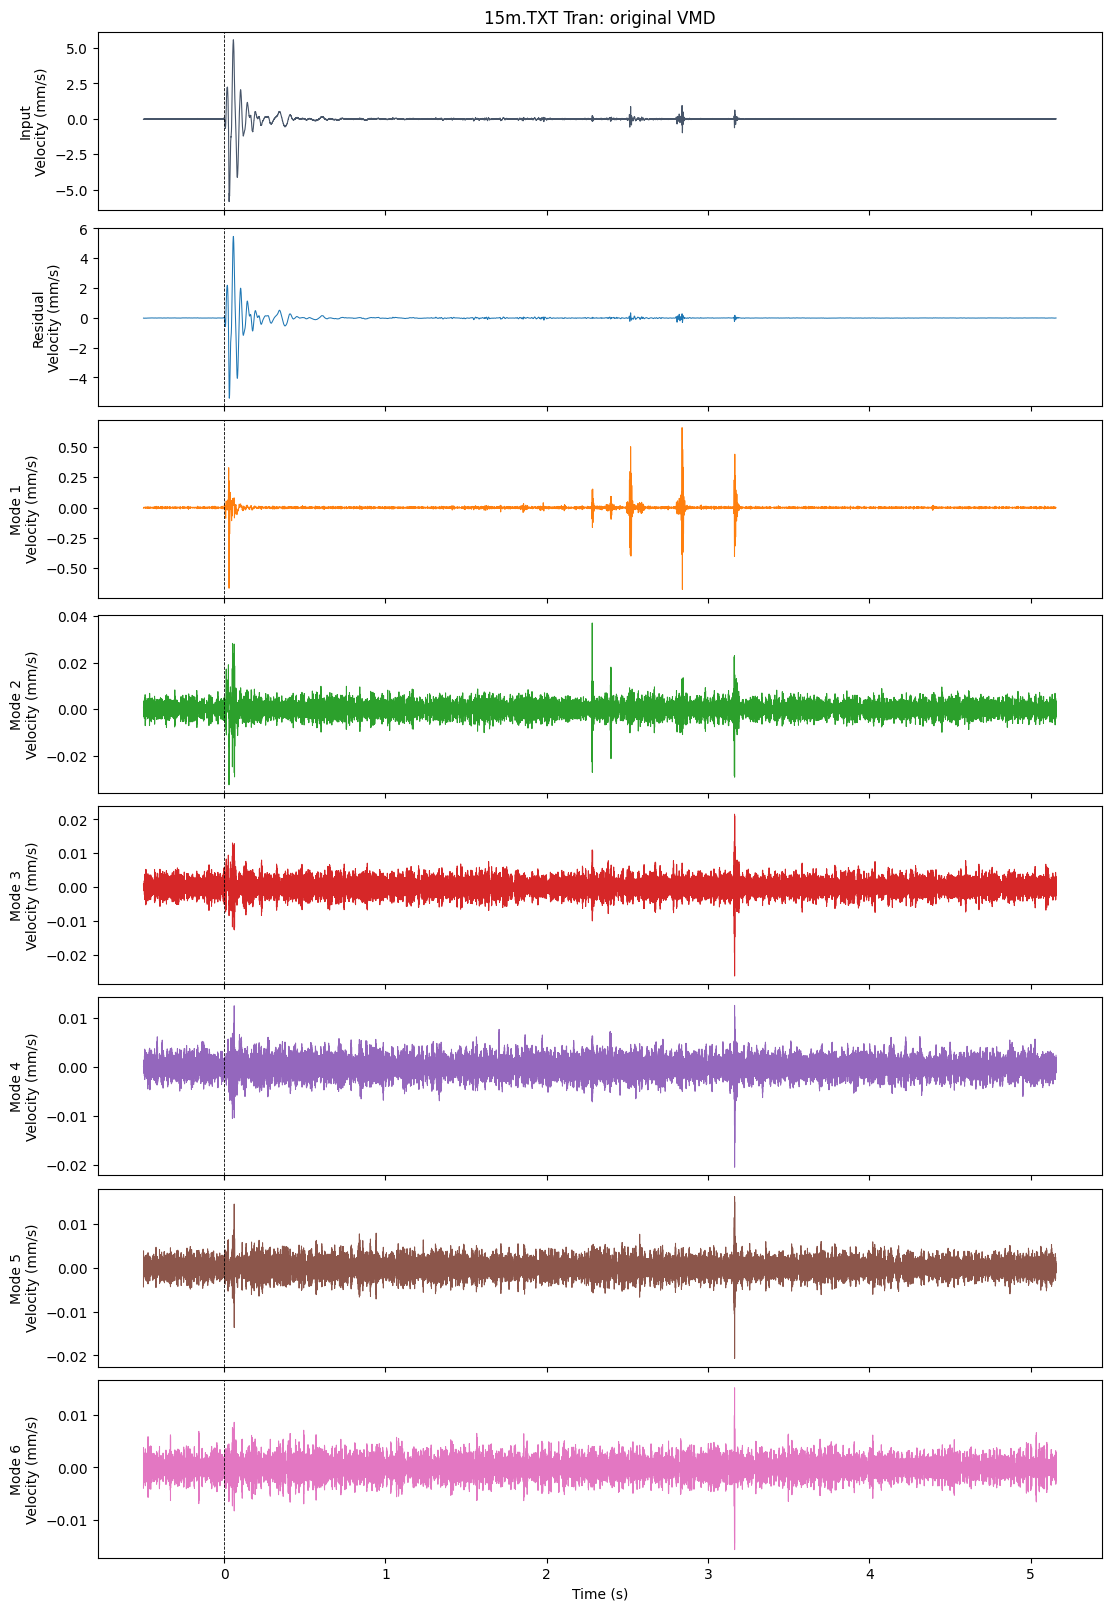

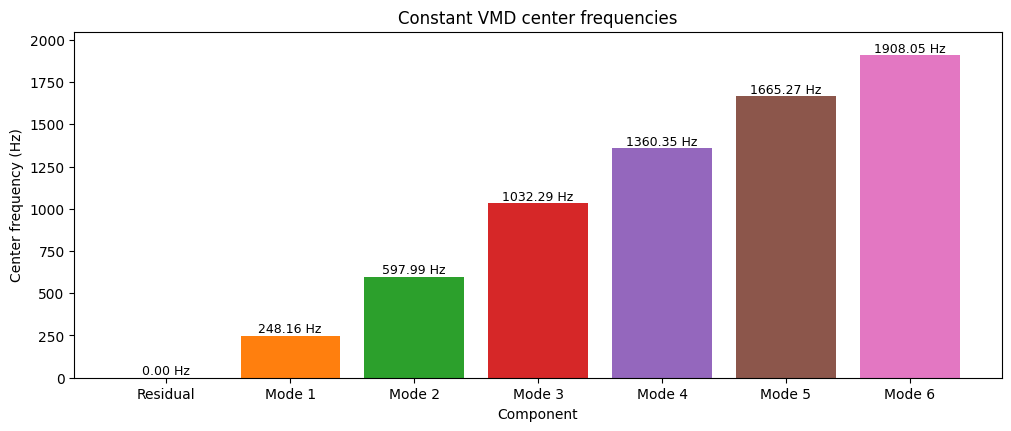

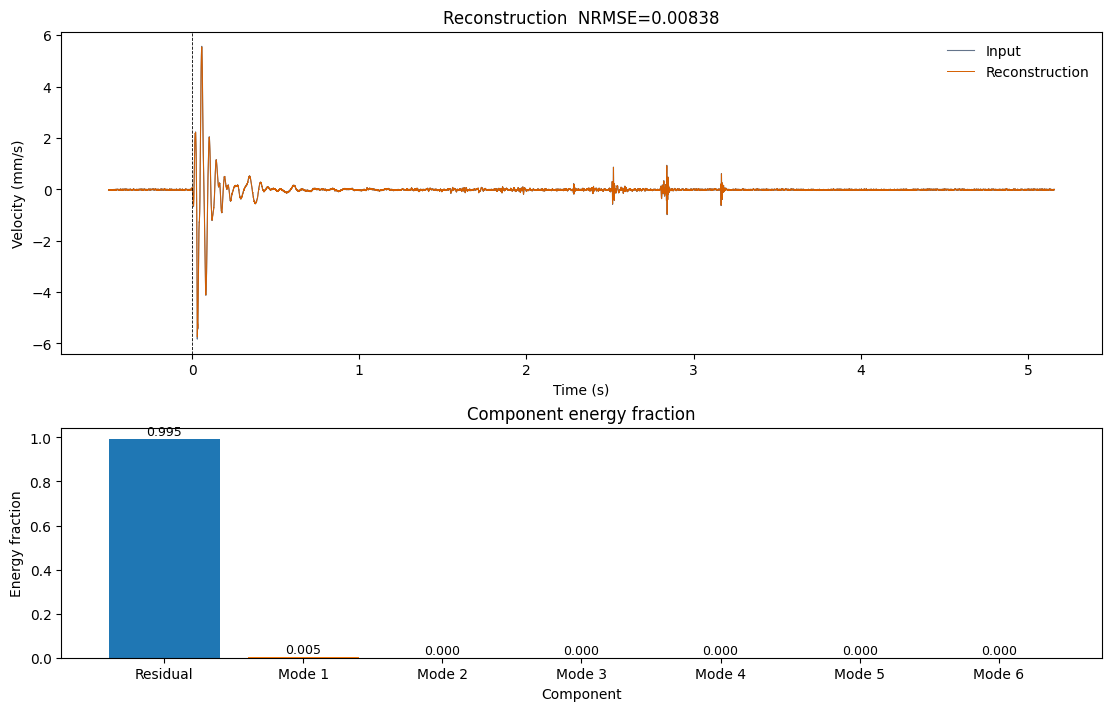

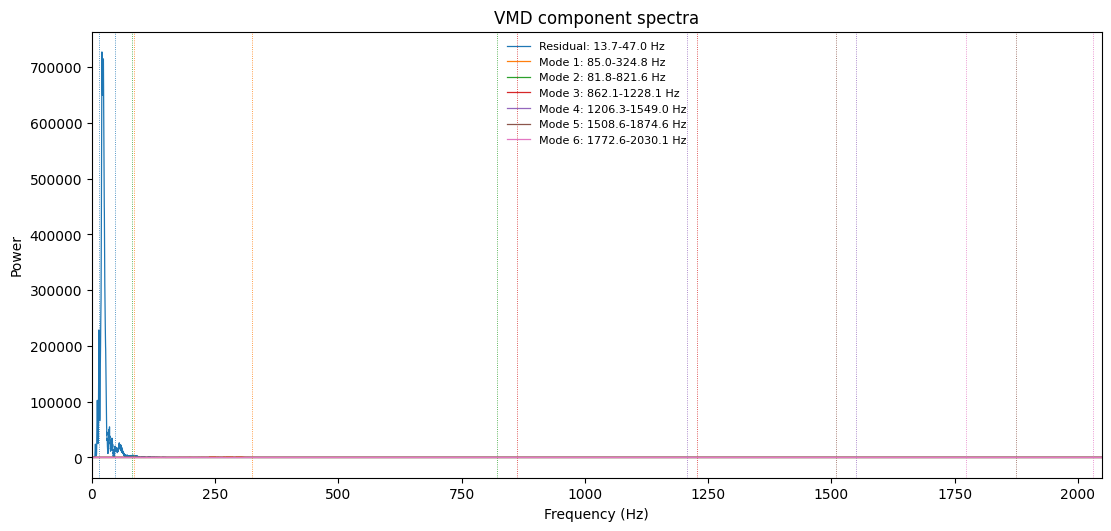

In [20]:
waveform = load_single_waveform(INPUT_FILE, DIRECTION)
estimated_memory_gb = estimate_original_vmd_memory_gb(
    1, waveform.values.size, K, N_FFT, MAX_ITERS
)
print("文件:", waveform.path.resolve())
print("方向:", waveform.direction)
print("采样率:", waveform.fs, "Hz")
print("样本数:", waveform.values.size)
print(
    "时间范围:",
    (float(waveform.time_s[0]), float(waveform.time_s[-1])),
    "s",
)
print(f"原始VMD粗略内存估算: {estimated_memory_gb:.2f} GB")
if estimated_memory_gb > 2.0:
    warnings.warn(
        "当前参数的原始VMD内存估算超过2 GB；"
        "请考虑降低MAX_ITERS或K。",
        RuntimeWarning,
    )

result = analyze_single_waveform_vmd(waveform)
figures = plot_vmd_results(waveform, result)
for figure in figures.values():
    display(figure)

## 7. 保存结果

In [ ]:
OUTPUT_DIR = Path("output/vmd_single_waveform")
if SAVE_OUTPUTS:
    save_vmd_results(OUTPUT_DIR, waveform, result, figures)
    print(f"结果已保存到: {OUTPUT_DIR.resolve()}")
else:
    print("SAVE_OUTPUTS=False：未写出结果文件。")